# Email/SMS Spam Classifier

End-to-end ML project:
1. Load and explore data
2. Preprocess text (TF-IDF)
3. Train multiple models and compare
4. Select the best model
5. Predict on new messages
6. Save model + vectorizer for the Streamlit app

**Dataset:** `mail_data.csv` — columns `Category` (ham/spam) and `Message` (SMS text).

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load and explore the data

In [2]:
df = pd.read_csv('mail_data.csv')
df.columns = ['Category', 'Message']
print(df.shape)
df.head()

(5572, 2)


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Category
ham     4825
spam     747
Name: count, dtype: int64

Missing values:
 Category    0
Message     0
dtype: int64


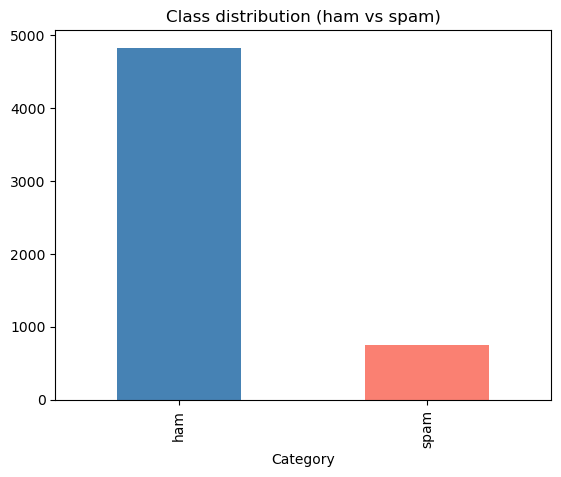

In [3]:
print(df['Category'].value_counts())
print('\nMissing values:\n', df.isnull().sum())

df['Category'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class distribution (ham vs spam)')
plt.show()

The dataset is imbalanced (~87% ham / ~13% spam), which is why we look at **precision/recall/F1**, not just accuracy.

## 3. Encode labels and split the data

In [4]:
df['label'] = df['Category'].map({'ham': 0, 'spam': 1})

X_train, X_test, y_train, y_test = train_test_split(
    df['Message'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 4457
Test size: 1115


## 4. Feature extraction with TF-IDF

In [5]:
tfidf = TfidfVectorizer(stop_words='english', max_df=0.9, min_df=2)

X_train_tf = tfidf.fit_transform(X_train)
X_test_tf = tfidf.transform(X_test)

print('Vocabulary size:', len(tfidf.vocabulary_))
print('Train matrix shape:', X_train_tf.shape)

Vocabulary size: 3371
Train matrix shape: (4457, 3371)


## 5. Train and compare multiple models

In [6]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear SVM': LinearSVC(),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_tf, y_train)
    preds = model.predict(X_test_tf)

    results[name] = {
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds)
    }
    trained_models[name] = model

results_df = pd.DataFrame(results).T.sort_values('f1', ascending=False)
results_df

,accuracy,precision,recall,f1
Linear SVM,0.981166,0.984848,0.872483,0.925267
Random Forest,0.976682,1.000000,0.825503,0.904412
Naive Bayes,0.973991,1.000000,0.805369,0.892193
Logistic Regression,0.971300,1.000000,0.785235,0.879699


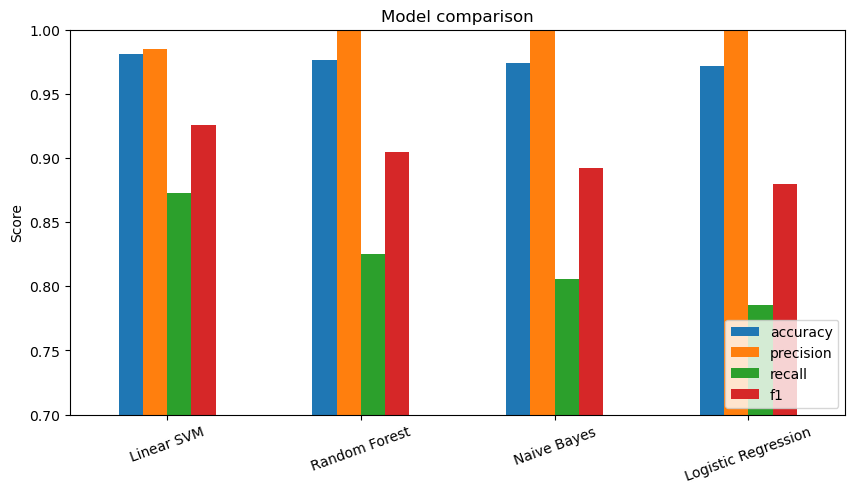

In [7]:
results_df.plot(kind='bar', figsize=(10, 5))
plt.title('Model comparison')
plt.ylabel('Score')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.show()

## 6. Select the best model automatically

In [8]:
# We pick the model with the highest F1-score (best balance of precision & recall,
# which matters most on this imbalanced dataset)
best_model_name = results_df['f1'].idxmax()
best_model = trained_models[best_model_name]

print(f'Best model: {best_model_name}')
print(results_df.loc[best_model_name])

Best model: Linear SVM
accuracy     0.981166
precision    0.984848
recall       0.872483
f1           0.925267
Name: Linear SVM, dtype: float64


              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.98      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



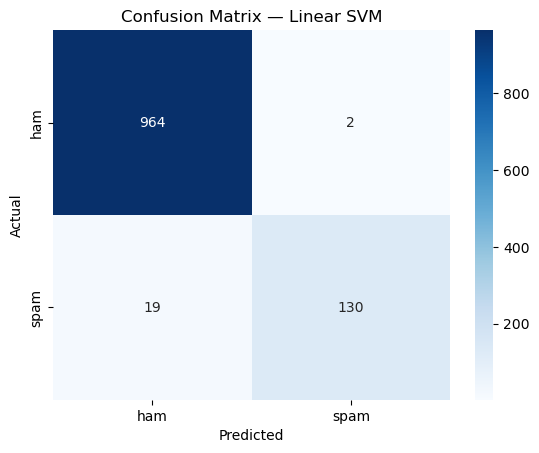

In [9]:
preds = best_model.predict(X_test_tf)

print(classification_report(y_test, preds, target_names=['ham', 'spam']))

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

## 7. Predict on new/custom messages

In [10]:
def predict_message(text, model=best_model, vectorizer=tfidf):
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    return 'SPAM' if pred == 1 else 'HAM'

sample_messages = [
    "Congratulations! You've WON a $1000 gift card. Click here to claim now!!!",
    "Hey, are we still on for lunch tomorrow at 1pm?",
    "URGENT: Your account has been suspended, verify immediately at this link",
    "Can you send me the report before end of day?"
]

for msg in sample_messages:
    print(f'{predict_message(msg):5s} -> {msg}')

SPAM  -> Congratulations! You've WON a $1000 gift card. Click here to claim now!!!
HAM   -> Hey, are we still on for lunch tomorrow at 1pm?
SPAM  -> URGENT: Your account has been suspended, verify immediately at this link
HAM   -> Can you send me the report before end of day?


## 8. Save the model + vectorizer (used by the Streamlit app)

In [11]:
with open('spam_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print('Saved spam_model.pkl and tfidf_vectorizer.pkl')
print('These files are loaded by app.py (the Streamlit app).')

Saved spam_model.pkl and tfidf_vectorizer.pkl
These files are loaded by app.py (the Streamlit app).
